# Visualización y análisis del modelo RF — Dataset PRO-ACT
## Sistema de Ayuda a la Decisión para predicción de progresión en ELA
### Asignatura: Sistemas de Ayuda a la Decisión Clínica

En este notebook se generan las visualizaciones finales a partir de los resultados del modelo Random Forest optimizado entrenado en el notebook 03. Se construye un dataset enriquecido con predicciones, valores SHAP y variables demográficas, se exporta para Tableau y se generan cinco gráficas de análisis clínico e interpretabilidad.

## 1. Carga de librerías, datos y modelo

Se importan las librerías necesarias y se cargan desde disco los datasets de test, las predicciones del modelo, los valores SHAP y el modelo Random Forest exportados por el notebook 03.

In [1]:
# ============================================================
# IMPORTACIÓN DESDE NOTEBOOK 3
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import os

# Ruta
ruta_out = r"C:\Users\Paula\SAD_ELA\datos_procesados/"

# ─────────────────────────────────────────────
# 1. CARGAR DATASETS
# ─────────────────────────────────────────────

X_test = pd.read_csv(
    ruta_out + r"\X_test.csv",
    sep=';',
    decimal=',',
    index_col=0
)

y_test = pd.read_csv(
    ruta_out + r"\y_test.csv",
    sep=';',
    decimal=',',
    index_col=0
).squeeze("columns")

X = pd.read_csv(
    ruta_out + r"\X_full.csv",
    sep=';',
    decimal=',',
    index_col=0
)

# ─────────────────────────────────────────────
# 2. CARGAR PREDICCIONES
# ─────────────────────────────────────────────

y_pred_rf_opt = np.load(ruta_out + r"\y_pred_rf_opt.npy")
y_prob_rf_opt = np.load(ruta_out + r"\y_prob_rf_opt.npy")

# ─────────────────────────────────────────────
# 3. CARGAR SHAP
# ─────────────────────────────────────────────

shap_rapida = np.load(ruta_out + r"\shap_rapida.npy")

# ─────────────────────────────────────────────
# 4. CARGAR MODELO
# ─────────────────────────────────────────────

rf_opt = joblib.load(ruta_out + r"\rf_opt.pkl")

# ─────────────────────────────────────────────
# CONFIRMACIÓN
# ─────────────────────────────────────────────

print("✅ Datos cargados correctamente")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"SHAP: {shap_rapida.shape}")

✅ Datos cargados correctamente
X_test: (444, 20)
y_test: (444,)
SHAP: (444, 20)


## 2. Construcción del dataset enriquecido

A partir del conjunto de test se construye un dataframe que incluye:
- Las **predicciones** del modelo (clase y probabilidad)
- La **clase real** de cada paciente
- El **tipo de predicción** (VP, VN, FP, FN)
- Variables legibles: sitio de inicio (revertido desde one-hot), sexo y grupo de edad
- Los **valores SHAP** por paciente como columnas adicionales

In [2]:
# CONSTRUIR DATAFRAME ENRIQUECIDO
df_export = X_test.copy().reset_index(drop=True)

# Predicciones
df_export['pred_progresion_rapida'] = y_pred_rf_opt
df_export['probabilidad_rapida']    = y_prob_rf_opt
df_export['clase_real']             = y_test.reset_index(drop=True)

# Etiquetas legibles
df_export['pred_etiqueta'] = df_export['pred_progresion_rapida'].map(
    {1: 'Rápida', 0: 'Lenta'}
)
df_export['real_etiqueta'] = df_export['clase_real'].map(
    {1: 'Rápida', 0: 'Lenta'}
)

# Tipo de predicción (VP, VN, FP, FN)
def clasificar(row):
    if row['clase_real'] == 1 and row['pred_progresion_rapida'] == 1: return 'VP'
    if row['clase_real'] == 0 and row['pred_progresion_rapida'] == 0: return 'VN'
    if row['clase_real'] == 0 and row['pred_progresion_rapida'] == 1: return 'FP'
    return 'FN'

df_export['tipo_pred'] = df_export.apply(clasificar, axis=1)

# Sitio de inicio: revertir one-hot a categoría legible
onset_cols = ['onset_limb', 'onset_bulbar', 'onset_spine',
              'onset_limb_bulbar', 'onset_other', 'onset_unknown']
onset_labels = {
    'onset_limb':       'Miembro',
    'onset_bulbar':     'Bulbar',
    'onset_spine':      'Espinal',
    'onset_limb_bulbar':'Miembro+Bulbar',
    'onset_other':      'Otro',
    'onset_unknown':    'Desconocido'
}

def get_onset(row):
    for col in onset_cols:
        if row[col] == 1:
            return onset_labels[col]
    return 'Desconocido'

df_export['sitio_inicio'] = df_export.apply(get_onset, axis=1)

# Sexo legible
df_export['sexo'] = df_export['Sex'].map({1: 'Masculino', 0: 'Femenino'})

# Grupo de edad
bins  = [0, 45, 55, 65, 75, 120]
labels_edad = ['<45', '45-54', '55-64', '65-74', '≥75']
df_export['grupo_edad'] = pd.cut(df_export['Age'], bins=bins, labels=labels_edad)

# SHAP values como columnas
shap_df = pd.DataFrame(
    shap_rapida,
    columns=['shap_' + c for c in X_test.columns]
).reset_index(drop=True)

df_export = pd.concat([df_export, shap_df], axis=1)

print(f"✅ Dataset enriquecido: {df_export.shape[0]} pacientes, {df_export.shape[1]} columnas")

✅ Dataset enriquecido: 444 pacientes, 49 columnas


## 3. Exportación de datasets para Tableau

Se generan tres archivos CSV para su uso en Tableau:
- `ela_predicciones_enriquecido.csv` → dataset principal con predicciones y SHAP por paciente
- `ela_shap_importance.csv` → importancia SHAP media por variable (para gráfico de barras)
- `ela_metricas_subgrupos.csv` → métricas del modelo por subgrupo demográfico (generado en la sección 7)

In [3]:
# 2. EXPORTAR CSVs PARA TABLEAU

# CSV principal
df_export.to_csv(ruta_out + 'ela_predicciones_enriquecido.csv', index=False)
print("✅ ela_predicciones_enriquecido.csv exportado")

# CSV de importancia SHAP media (para gráfico de barras en Tableau)
shap_importance = pd.DataFrame({
    'feature':    X_test.columns.tolist(),
    'shap_medio': np.abs(shap_rapida).mean(axis=0)
}).sort_values('shap_medio', ascending=False)

shap_importance.to_csv(ruta_out + 'ela_shap_importance.csv', index=False)
print("✅ ela_shap_importance.csv exportado")

✅ ela_predicciones_enriquecido.csv exportado
✅ ela_shap_importance.csv exportado


## 4. Visualización A — Progresión por sitio de inicio

Se representan las distribuciones de progresión rápida y lenta según el sitio de inicio de la enfermedad mediante barras apiladas al 100% y un gráfico de barras horizontales con el porcentaje de progresión rápida y el tamaño de cada grupo.

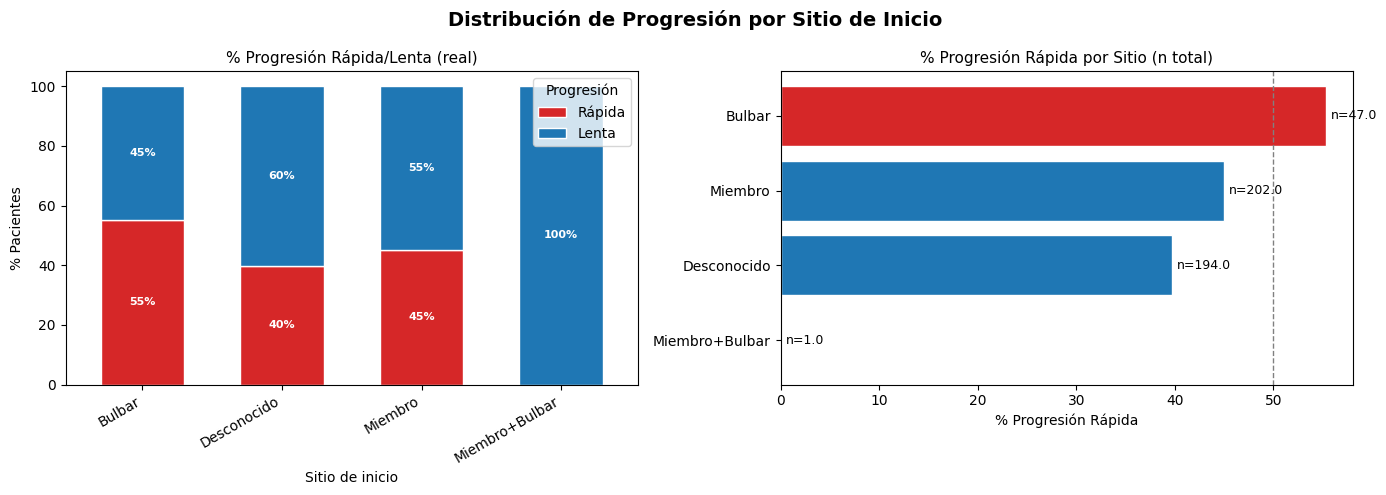

✅ Viz A guardada


In [4]:
# VIZ A — Progresión por sitio de inicio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Progresión por Sitio de Inicio', fontsize=14, fontweight='bold')

# Barras apiladas 100%
ct = pd.crosstab(df_export['sitio_inicio'], df_export['real_etiqueta'], normalize='index') * 100
ct = ct.reindex(columns=['Rápida', 'Lenta'])
ct.plot(kind='bar', stacked=True, ax=axes[0],
        color=['#d62728', '#1f77b4'], edgecolor='white', width=0.6)
axes[0].set_title('% Progresión Rápida/Lenta (real)', fontsize=11)
axes[0].set_xlabel('Sitio de inicio')
axes[0].set_ylabel('% Pacientes')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Progresión', loc='upper right')

for p in axes[0].patches:
    h = p.get_height()
    if h > 5:
        axes[0].annotate(f'{h:.0f}%',
                         (p.get_x() + p.get_width() / 2, p.get_y() + h / 2),
                         ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# N por sitio
n_sitio = df_export.groupby('sitio_inicio')['clase_real'].agg(['sum', 'count'])
n_sitio.columns = ['n_rapida', 'n_total']
n_sitio['pct_rapida'] = (n_sitio['n_rapida'] / n_sitio['n_total'] * 100).round(1)
n_sitio = n_sitio.sort_values('pct_rapida', ascending=True)

axes[1].barh(n_sitio.index, n_sitio['pct_rapida'],
             color=['#d62728' if v > 50 else '#1f77b4' for v in n_sitio['pct_rapida']],
             edgecolor='white')
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('% Progresión Rápida por Sitio (n total)', fontsize=11)
axes[1].set_xlabel('% Progresión Rápida')
for i, (idx, row) in enumerate(n_sitio.iterrows()):
    axes[1].text(row['pct_rapida'] + 0.5, i, f"n={row['n_total']}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig(ruta_out + 'viz_A_progresion_por_sitio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz A guardada")

## 5. Visualización B — Distribución por edad y sexo

Un heatmap muestra el porcentaje de progresión rápida cruzado por grupo de edad y sexo. Un boxplot complementario compara la distribución de la edad entre pacientes de progresión lenta y rápida.

C:\Users\Paula\AppData\Local\Temp\ipykernel_127300\1935555291.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_export.pivot_table(


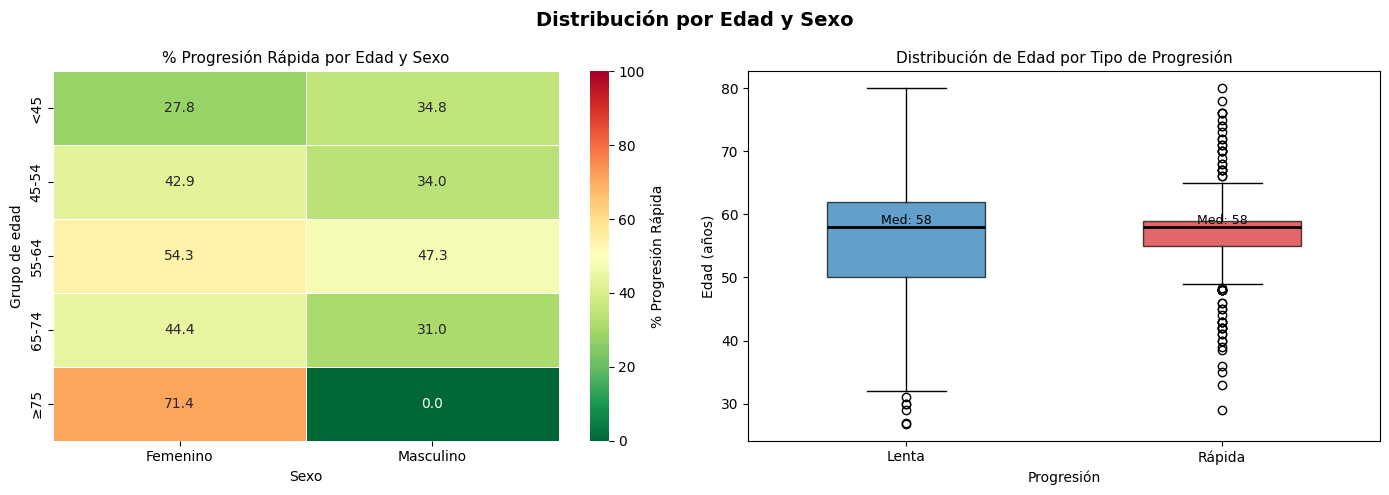

✅ Viz B guardada


In [5]:
# VIZ B — Distribución edad y sexo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución por Edad y Sexo', fontsize=14, fontweight='bold')

# Heatmap edad x sexo → % progresión rápida
pivot = df_export.pivot_table(
    values='clase_real', index='grupo_edad', columns='sexo', aggfunc='mean'
) * 100

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            vmin=0, vmax=100, ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '% Progresión Rápida'})
axes[0].set_title('% Progresión Rápida por Edad y Sexo', fontsize=11)
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Grupo de edad')

# Boxplot edad según progresión real
colores = {'Lenta': '#1f77b4', 'Rápida': '#d62728'}
grupos  = [df_export[df_export['real_etiqueta'] == e]['Age'] for e in ['Lenta', 'Rápida']]
bp = axes[1].boxplot(grupos, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#1f77b4', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(['Lenta', 'Rápida'])
axes[1].set_title('Distribución de Edad por Tipo de Progresión', fontsize=11)
axes[1].set_ylabel('Edad (años)')
axes[1].set_xlabel('Progresión')

# Añadir medias
for i, g in enumerate(grupos, 1):
    axes[1].text(i, g.median() + 0.5, f'Med: {g.median():.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(ruta_out + 'viz_B_edad_sexo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz B guardada")

## 6. Visualización C — ALSFRS basal vs probabilidad predicha

Un scatter plot enfrenta la puntuación ALSFRS-R basal con la probabilidad predicha por el modelo, coloreando cada punto por la clase real. Se complementa con violin plots de las cuatro subescalas (bulbar, motor fino, motor grueso y respiratorio) separadas por tipo de progresión.

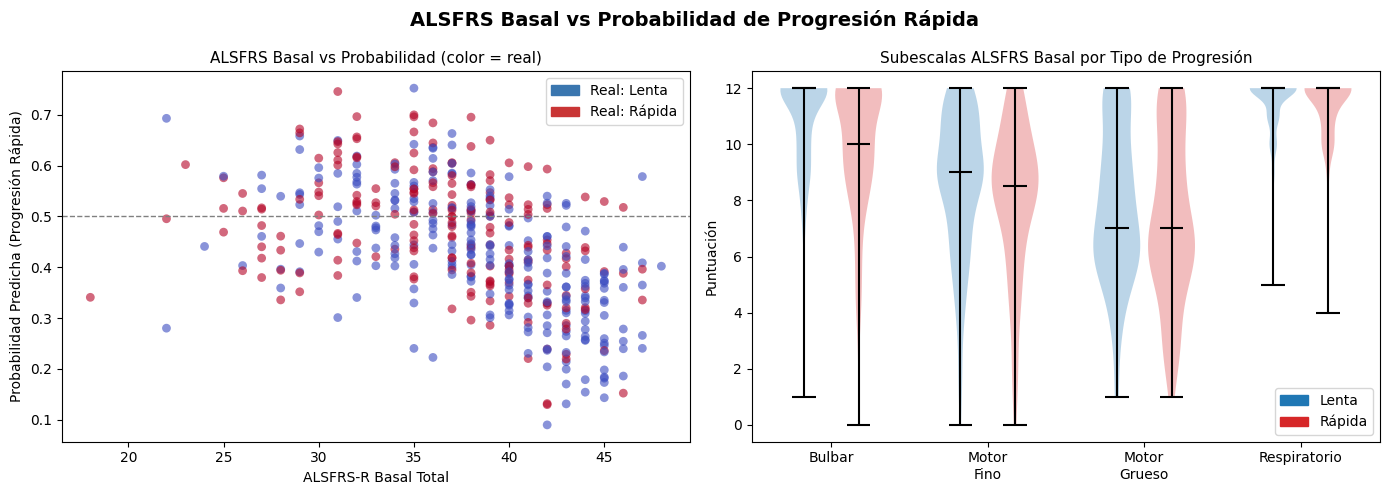

✅ Viz C guardada


In [6]:
# VIZ C — ALSFRS basal vs velocidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ALSFRS Basal vs Probabilidad de Progresión Rápida', fontsize=14, fontweight='bold')

# Scatter ALSFRS basal vs probabilidad predicha
scatter = axes[0].scatter(
    df_export['alsfrs_basal_total'],
    df_export['probabilidad_rapida'],
    c=df_export['clase_real'],
    cmap='coolwarm', alpha=0.6, edgecolors='none', s=40
)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Umbral 0.5')
axes[0].set_xlabel('ALSFRS-R Basal Total')
axes[0].set_ylabel('Probabilidad Predicha (Progresión Rápida)')
axes[0].set_title('ALSFRS Basal vs Probabilidad (color = real)', fontsize=11)
legend_elements = [
    mpatches.Patch(color='#3a76af', label='Real: Lenta'),
    mpatches.Patch(color='#c93535', label='Real: Rápida')
]
axes[0].legend(handles=legend_elements)

# Subescalas ALSFRS vs probabilidad (violin)
subescalas = ['basal_bulbar', 'basal_motor_fino', 'basal_motor_grueso', 'basal_respiratorio']
labels_sub = ['Bulbar', 'Motor\nFino', 'Motor\nGrueso', 'Respiratorio']

data_violin = []
for sub in subescalas:
    for clase, label in [(0, 'Lenta'), (1, 'Rápida')]:
        vals = df_export[df_export['clase_real'] == clase][sub].dropna()
        data_violin.append({'Subescala': sub, 'Progresión': label, 'Valor': vals.values})

pos_lenta  = [1, 3, 5, 7]
pos_rapida = [1.7, 3.7, 5.7, 7.7]

for i, sub in enumerate(subescalas):
    v_lenta  = df_export[df_export['clase_real'] == 0][sub].dropna()
    v_rapida = df_export[df_export['clase_real'] == 1][sub].dropna()
    vp = axes[1].violinplot([v_lenta, v_rapida],
                             positions=[pos_lenta[i], pos_rapida[i]],
                             widths=0.6, showmedians=True)
    vp['bodies'][0].set_facecolor('#1f77b4')
    vp['bodies'][1].set_facecolor('#d62728')
    for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        vp[part].set_color('black')

mid = [(a+b)/2 for a, b in zip(pos_lenta, pos_rapida)]
axes[1].set_xticks(mid)
axes[1].set_xticklabels(labels_sub)
axes[1].set_title('Subescalas ALSFRS Basal por Tipo de Progresión', fontsize=11)
axes[1].set_ylabel('Puntuación')
patch_lenta  = mpatches.Patch(color='#1f77b4', label='Lenta')
patch_rapida = mpatches.Patch(color='#d62728', label='Rápida')
axes[1].legend(handles=[patch_lenta, patch_rapida])

plt.tight_layout()
plt.savefig(ruta_out + 'viz_C_alsfrs_vs_progresion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz C guardada")

## 7. Visualización D — Interpretabilidad SHAP

Se representan las 15 variables más importantes según el valor SHAP medio absoluto en un gráfico de barras, y el beeswarm plot de SHAP que muestra la dirección del efecto de cada variable sobre la predicción de progresión rápida.

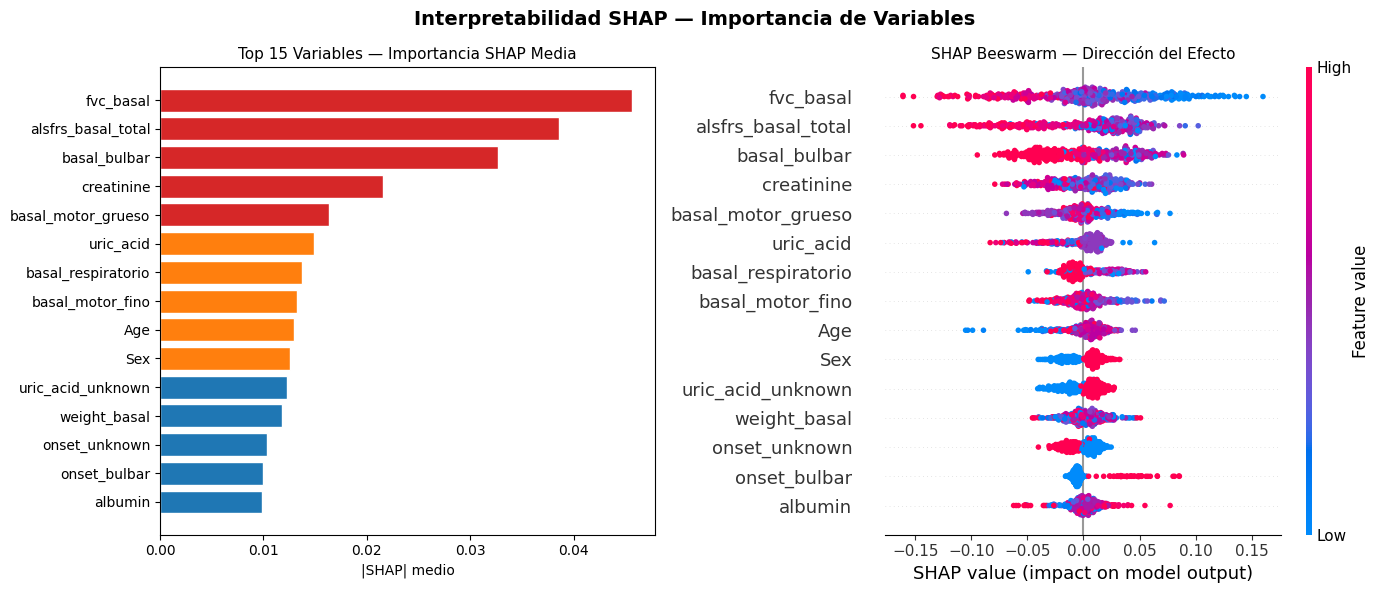

✅ Viz D guardada


In [7]:
#  VIZ D — SHAP Importancia Global
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Interpretabilidad SHAP — Importancia de Variables', fontsize=14, fontweight='bold')

# Bar chart importancia media |SHAP|
shap_importance_plot = shap_importance.head(15)
colors_shap = ['#d62728' if i < 5 else '#ff7f0e' if i < 10 else '#1f77b4'
               for i in range(len(shap_importance_plot))]

axes[0].barh(shap_importance_plot['feature'][::-1],
             shap_importance_plot['shap_medio'][::-1],
             color=colors_shap[::-1], edgecolor='white')
axes[0].set_title('Top 15 Variables — Importancia SHAP Media', fontsize=11)
axes[0].set_xlabel('|SHAP| medio')
axes[0].axvline(0, color='black', linewidth=0.5)

# Beeswarm / summary plot de SHAP
plt.sca(axes[1])
shap.summary_plot(
    shap_rapida,
    X_test,
    max_display=15,
    show=False,
    plot_size=None
)
axes[1].set_title('SHAP Beeswarm — Dirección del Efecto', fontsize=11)

plt.tight_layout()
plt.savefig(ruta_out + 'viz_D_shap_importancia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz D guardada")

## 8. Visualización E — Rendimiento del modelo por subgrupos

Para evaluar la equidad del modelo se calculan Recall, Precision, F1 y AUC sobre subgrupos definidos por sexo, sitio de inicio y grupo de edad. Se representan en un gráfico de barras horizontales con líneas de referencia del rendimiento global, y se imprime una tabla resumen.

✅ ela_metricas_subgrupos.csv exportado
                Subgrupo   N   Recall  Precision       F1      AUC
          sexo=Masculino 268 0.336449   0.514286 0.406780 0.587740
           sexo=Femenino 176 0.643678   0.608696 0.625698 0.668604
    sitio_inicio=Miembro 202 0.428571   0.639344 0.513158 0.674290
sitio_inicio=Desconocido 194 0.402597   0.469697 0.433566 0.588301
     sitio_inicio=Bulbar  47 0.846154   0.647059 0.733333 0.580586
          grupo_edad=<45  64 0.142857   0.333333 0.200000 0.545958
        grupo_edad=45-54  78 0.448276   0.464286 0.456140 0.615764
        grupo_edad=55-64 234 0.542373   0.633663 0.584475 0.627922
        grupo_edad=65-74  60 0.428571   0.428571 0.428571 0.650794


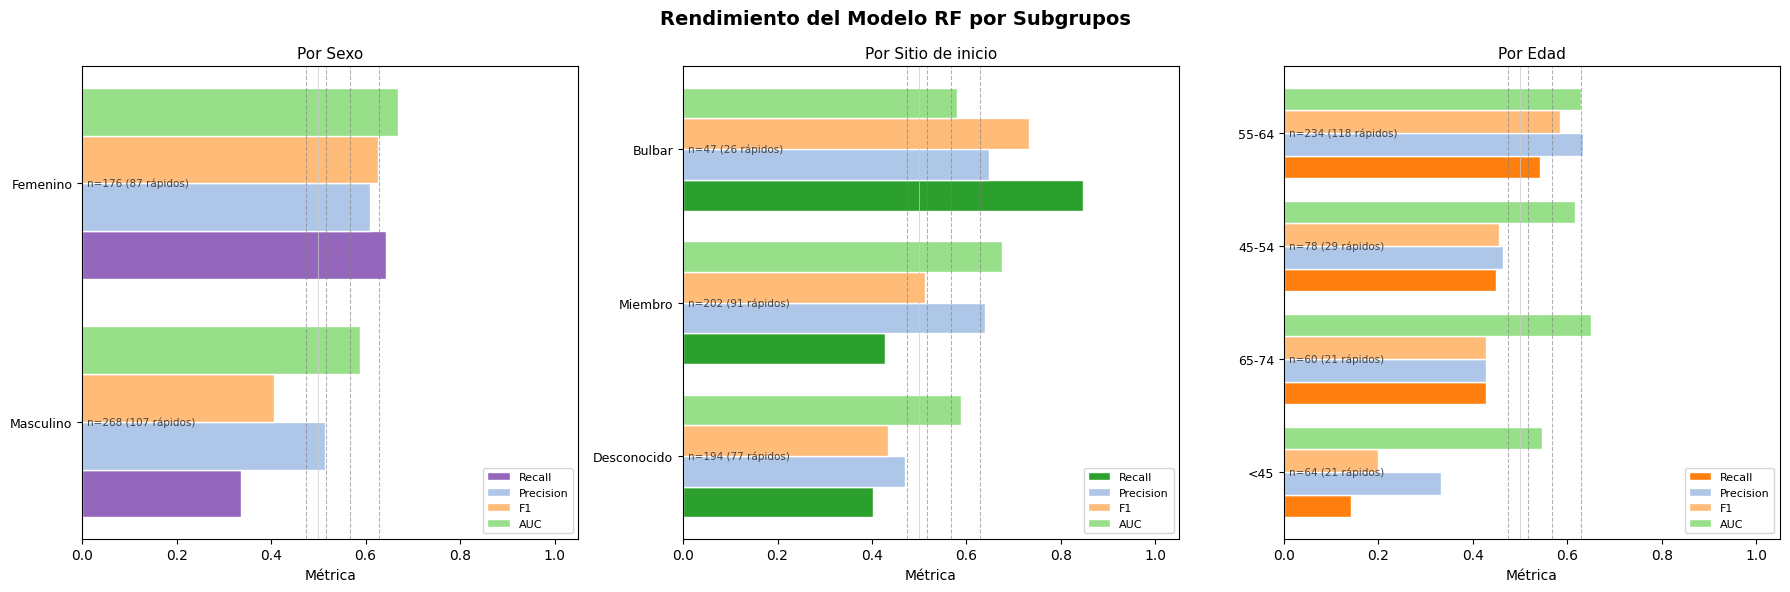

✅ Viz E guardada

📊 TABLA RESUMEN DE EQUIDAD DEL MODELO
────────────────────────────────────────────────────────────
Subgrupo                      N   Recall       F1      AUC
────────────────────────────────────────────────────────────
55-64                       234    0.542    0.584    0.628
45-54                        78    0.448    0.456    0.616
65-74                        60    0.429    0.429    0.651
<45                          64    0.143    0.200    0.546
Femenino                    176    0.644    0.626    0.669
Masculino                   268    0.336    0.407    0.588
Bulbar                       47    0.846    0.733    0.581
Miembro                     202    0.429    0.513    0.674
Desconocido                 194    0.403    0.434    0.588
────────────────────────────────────────────────────────────
GLOBAL                      444    0.474    0.517    0.629


In [8]:
# 7. VIZ E — RENDIMIENTO POR SUBGRUPOS
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

def metricas_subgrupo(df, nombre_grupo, valor_grupo):
    """Calcula métricas de clasificación para un subgrupo."""
    mask = df[nombre_grupo] == valor_grupo
    sub  = df[mask]
    if len(sub) < 10:  # evitar subgrupos muy pequeños
        return None
    y_r = sub['clase_real']
    y_p = sub['pred_progresion_rapida']
    y_b = sub['probabilidad_rapida']
    return {
        'Subgrupo'  : f"{nombre_grupo}={valor_grupo}",
        'N'         : len(sub),
        'N_rapida'  : int(y_r.sum()),
        'Recall'    : recall_score(y_r, y_p, zero_division=0),
        'Precision' : precision_score(y_r, y_p, zero_division=0),
        'F1'        : f1_score(y_r, y_p, zero_division=0),
        'AUC'       : roc_auc_score(y_r, y_b) if y_r.nunique() > 1 else np.nan,
    }

# ── Calcular métricas por subgrupo ──────────
filas = []

# Por sexo
for v in df_export['sexo'].dropna().unique():
    r = metricas_subgrupo(df_export, 'sexo', v)
    if r: filas.append({**r, 'Dimensión': 'Sexo'})

# Por sitio de inicio
for v in df_export['sitio_inicio'].dropna().unique():
    r = metricas_subgrupo(df_export, 'sitio_inicio', v)
    if r: filas.append({**r, 'Dimensión': 'Sitio de inicio'})

# Por grupo de edad
for v in labels_edad:
    r = metricas_subgrupo(df_export, 'grupo_edad', v)
    if r: filas.append({**r, 'Dimensión': 'Edad'})

df_sub = pd.DataFrame(filas)
df_sub.to_csv(ruta_out + 'ela_metricas_subgrupos.csv', index=False)
print("✅ ela_metricas_subgrupos.csv exportado")
print(df_sub[['Subgrupo','N','Recall','Precision','F1','AUC']].to_string(index=False))

# ── Plot ────────────────────────────────────
metricas_plot = ['Recall', 'Precision', 'F1', 'AUC']
dimensiones   = ['Sexo', 'Sitio de inicio', 'Edad']
colores_dim   = {'Sexo': '#9467bd', 'Sitio de inicio': '#2ca02c', 'Edad': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle('Rendimiento del Modelo RF por Subgrupos', fontsize=14, fontweight='bold')

for ax, dim in zip(axes, dimensiones):
    sub = df_sub[df_sub['Dimensión'] == dim].copy()
    sub = sub.sort_values('Recall', ascending=True)

    x      = np.arange(len(sub))
    width  = 0.2
    color_base = colores_dim[dim]

    # 4 barras por subgrupo: Recall, Precision, F1, AUC
    colores_m = [color_base, '#aec7e8', '#ffbb78', '#98df8a']
    for i, (metrica, col) in enumerate(zip(metricas_plot, colores_m)):
        bars = ax.barh(x + i * width, sub[metrica], height=width,
                       label=metrica, color=col, edgecolor='white')

    # Línea de referencia global
    y_r_global = df_export['clase_real']
    y_p_global = df_export['pred_progresion_rapida']
    y_b_global = df_export['probabilidad_rapida']
    globales = {
        'Recall'   : recall_score(y_r_global, y_p_global),
        'Precision': precision_score(y_r_global, y_p_global),
        'F1'       : f1_score(y_r_global, y_p_global),
        'AUC'      : roc_auc_score(y_r_global, y_b_global),
    }
    for i, metrica in enumerate(metricas_plot):
        ax.axvline(globales[metrica], color='gray', linestyle='--',
                   linewidth=0.8, alpha=0.6)

    # Etiquetas N
    for j, (_, row) in enumerate(sub.iterrows()):
        ax.text(0.01, j + 1.5 * width,
                f"n={row['N']} ({row['N_rapida']} rápidos)",
                va='center', fontsize=7.5, color='#444')

    ax.set_yticks(x + 1.5 * width)
    ax.set_yticklabels(
        [s.replace('sitio_inicio=', '').replace('sexo=', '').replace('grupo_edad=', '')
         for s in sub['Subgrupo']],
        fontsize=9
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Métrica')
    ax.set_title(f'Por {dim}', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.axvline(0.5, color='#ccc', linewidth=0.5)

plt.tight_layout()
plt.savefig(ruta_out + 'viz_E_rendimiento_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Viz E guardada")

# ── Tabla resumen de equidad ─────────────────
print("\n📊 TABLA RESUMEN DE EQUIDAD DEL MODELO")
print("─" * 60)
print(f"{'Subgrupo':<25} {'N':>5} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("─" * 60)
for _, row in df_sub.sort_values(['Dimensión','Recall'], ascending=[True, False]).iterrows():
    nombre = row['Subgrupo'].split('=')[1] if '=' in row['Subgrupo'] else row['Subgrupo']
    auc_str = f"{row['AUC']:.3f}" if not np.isnan(row['AUC']) else '  N/A'
    print(f"{nombre:<25} {int(row['N']):>5} {row['Recall']:>8.3f} {row['F1']:>8.3f} {auc_str:>8}")
print("─" * 60)
print(f"{'GLOBAL':<25} {len(df_export):>5} {globales['Recall']:>8.3f} "
      f"{globales['F1']:>8.3f} {globales['AUC']:>8.3f}")

## 9. Resumen de archivos generados

Se listan todos los archivos exportados durante la ejecución del notebook: datasets CSV para Tableau y las cinco imágenes de visualización.

In [9]:
# 8. RESUMEN FINAL
print("\n" + "="*55)
print("📁 ARCHIVOS GENERADOS EN", ruta_out)
print("="*55)
print("  📊 ela_predicciones_enriquecido.csv  → Tableau (principal)")
print("  📊 ela_shap_importance.csv           → Tableau (SHAP barras)")
print("  🖼  viz_A_progresion_por_sitio.png")
print("  🖼  viz_B_edad_sexo.png")
print("  🖼  viz_C_alsfrs_vs_progresion.png")
print("  🖼  viz_D_shap_importancia.png")
print("  🖼  viz_E_rendimiento_subgrupos.png")
print("  📊 ela_metricas_subgrupos.csv        → Tableau (equidad)")
print("="*55)
print(f"\n📋 Pacientes exportados : {len(df_export)}")
print(f"   Progresión rápida    : {df_export['clase_real'].sum()} ({df_export['clase_real'].mean()*100:.1f}%)")
print(f"   Progresión lenta     : {(df_export['clase_real']==0).sum()} ({(df_export['clase_real']==0).mean()*100:.1f}%)")
print(f"   Columnas totales     : {df_export.shape[1]}")


📁 ARCHIVOS GENERADOS EN C:\Users\Paula\SAD_ELA\datos_procesados/
  📊 ela_predicciones_enriquecido.csv  → Tableau (principal)
  📊 ela_shap_importance.csv           → Tableau (SHAP barras)
  🖼  viz_A_progresion_por_sitio.png
  🖼  viz_B_edad_sexo.png
  🖼  viz_C_alsfrs_vs_progresion.png
  🖼  viz_D_shap_importancia.png
  🖼  viz_E_rendimiento_subgrupos.png
  📊 ela_metricas_subgrupos.csv        → Tableau (equidad)

📋 Pacientes exportados : 444
   Progresión rápida    : 194 (43.7%)
   Progresión lenta     : 250 (56.3%)
   Columnas totales     : 49
